# Réplica del 2.º puesto del PHM Data Challenge 2019 — Enfoque híbrido (Kong *et al.*, 2020)

Réplica fiel de **"A Hybrid Approach of Data-driven and Physics-based Methods for Estimation and
Prediction of Fatigue Crack Growth"** (Kong, Jo, Jung, Ha, Shin, Yoon, Sun, Seo & Jeon; *IJPHM*, 2020),
la entrada que obtuvo el **2.º puesto** en el Data Challenge de la PHM Society 2019.

**Objetivo del challenge**: estimar la longitud de grieta por fatiga en especímenes de aluminio remachado
(T7 y T8) a partir de señales de ondas Lamb (cuando existen) y **predecir** la longitud en los ciclos
posteriores sin señal.

**Método híbrido del paper** (Fig. 5):

1. **Método data-driven** (con señales Lamb) — filtro paso-banda (150–350 kHz) + alineación de fase,
   extracción de 8 features candidatas en la ventana del modo S0, estandarización, *random forest* con
   optimización de hiperparámetros por *grid search* (`max_depth ∈ {1,2,3}`, `n_trees ∈ {5,10,15,20,25}`),
   validación cruzada *k*-fold por especimen (T1–T4, T6; **T5 excluido como outlier**), selección de
   features y **ensemble de 20 modelos**.
2. **Método físico** (sin señales Lamb):
   * **T7** (misma carga): *ensemble prognostics* con actualización de pesos tipo filtro de partículas
     simplificado sobre modelos doble-exponenciales (Ec. 6) ajustados a T1, T3, T4, T6.
   * **T8** (carga variable): ecuación de **Walker** (Ec. 8–11), parámetros `d = {C0, γ, m, σ_FC}`
     optimizados con algoritmo evolutivo minimizando el error ponderado i² (Ec. 12), promediando
     **100 modelos Monte Carlo**.

**Resultados de referencia del paper (Tabla 3)**: RMSE(T7) = 0.2021, RMSE(T8) = 0.551,
*penalty score* del challenge = **7.63**.

> Las clases del pipeline están en este directorio: `data_loader.py`, `signal_processing.py`,
> `features.py`, `crack_estimator.py`, `physics_models.py`, `scoring.py`, `pipeline.py`.
> Las desviaciones respecto al paper (todas forzadas por ambigüedades del texto o anomalías de la copia
> del dataset) están documentadas en los docstrings y se resumen al final del notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline import HybridPipeline, PAPER_PREDICTIONS, PREDICTION_CYCLES
from signal_processing import SignalPreprocessor, bandpass_filter, DT_S
from features import FEATURE_NAMES, OPTIMAL_FEATURES
from scoring import score_table, penalty_score, rmse_mm

pd.set_option("display.width", 200)
np.random.seed(0)

# Paleta categórica fija por especimen (orden fijo, nunca ciclada)
COLOR = {"T1": "#2a78d6", "T2": "#008300", "T3": "#e87ba4", "T4": "#eda100",
         "T5": "#8a8987", "T6": "#1baf7a", "T7": "#eb6834", "T8": "#4a3aa7"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linewidth": 0.5, "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10})

DATA_ROOT = "../PHMDC2019_Data"
pipe = HybridPipeline(DATA_ROOT)
all_features = pipe.build_feature_tables()
print(f"{len(all_features)} filas de features ({all_features.specimen.nunique()} especímenes)")

45 filas de features (8 especímenes)


## 1. Dataset (PHM 2019 Data Challenge)

Ocho especímenes de junta remachada de aluminio 2024-T3. Sensores piezoeléctricos actuador/receptor a
161 mm; en cada "ciclo de medida" se registran 200 µs a 20 MHz (dos repeticiones, `signal_1`/`signal_2`).
T1–T6 (entrenamiento) traen la longitud de grieta medida ópticamente; de T7/T8 (validación) solo se
proporcionaron señales para los primeros ciclos, y el resto debía predecirse. T1–T7 con carga constante
(4.77–100.21 MPa) y T8 con carga variable (bloques de 1000 ciclos: 500 a 90 MPa máx + 500 a 100.21 MPa máx).

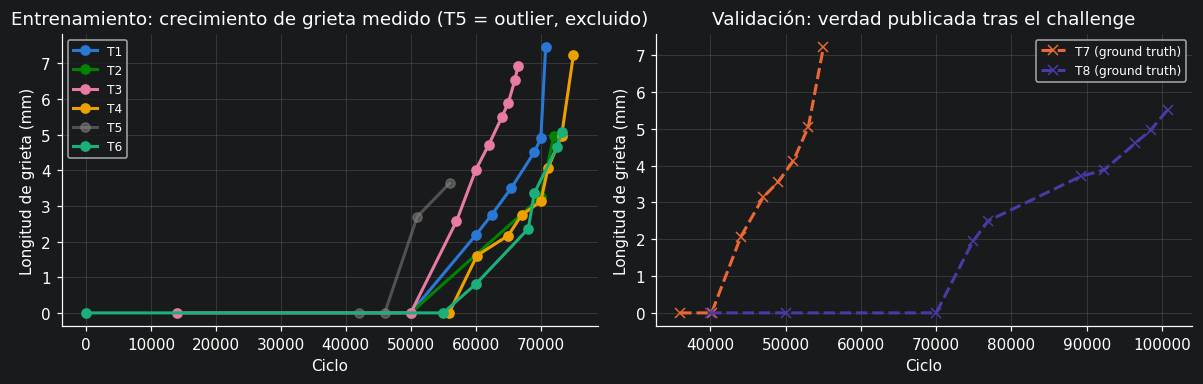

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name in ["T1", "T2", "T3", "T4", "T5", "T6"]:
    d = pipe.specimens[name].description
    axes[0].plot(d.cycle, d.crack_length_mm, "o-", color=COLOR[name], label=name,
                 alpha=0.5 if name == "T5" else 1.0)
axes[0].set(xlabel="Ciclo", ylabel="Longitud de grieta (mm)",
            title="Entrenamiento: crecimiento de grieta medido (T5 = outlier, excluido)")
axes[0].legend(fontsize=8)
for name in ["T7", "T8"]:
    d = pipe.specimens[name].description
    axes[1].plot(d.cycle, d.crack_length_mm, "x--", color=COLOR[name], label=f"{name} (ground truth)")
axes[1].set(xlabel="Ciclo", ylabel="Longitud de grieta (mm)",
            title="Validación: verdad publicada tras el challenge")
axes[1].legend(fontsize=8)
fig.tight_layout()

## 2. Preprocesado de señales (Sec. 3.2.1)

Dos técnicas: **(1)** filtro paso-banda Butterworth de 150–350 kHz (elimina ruido fuera de la banda del
*tone burst* de ~200 kHz; tras filtrar, las dos repeticiones son casi idénticas y se usa `signal_1`);
**(2)** **alineación de fase** basada en el máximo del actuador (`ch1`), que compensa las diferencias de
fase entre pares de sensores. Tras alinear, el modo S0 principal queda separado en una ventana temporal
fija (Fig. 4 del paper), de la que se extraen las features.

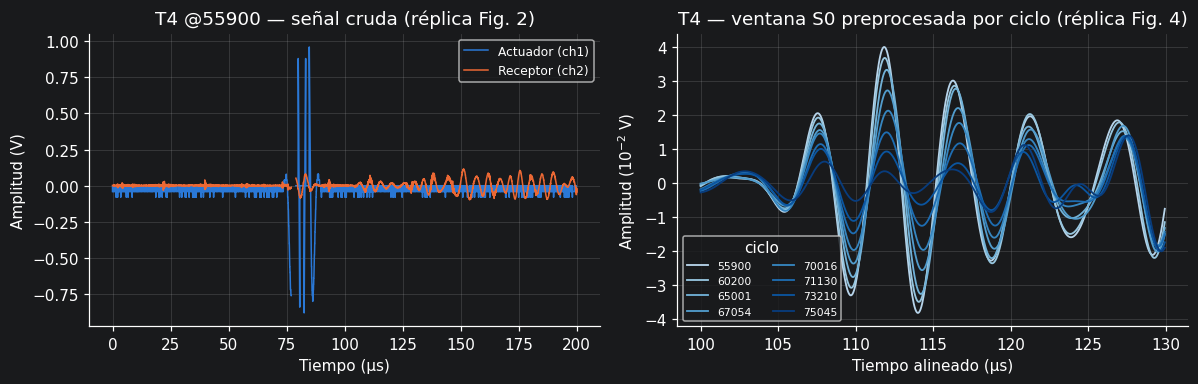

In [3]:
df_raw = pipe.specimens["T4"].signal(55900)
t_us = df_raw["time"].to_numpy() * 1e6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(t_us, df_raw["ch1"], color="#2a78d6", lw=1, label="Actuador (ch1)")
axes[0].plot(t_us, df_raw["ch2"], color="#eb6834", lw=1, label="Receptor (ch2)")
axes[0].set(xlabel="Tiempo (µs)", ylabel="Amplitud (V)", title="T4 @55900 — señal cruda (réplica Fig. 2)")
axes[0].legend(fontsize=8)

# Réplica de la Fig. 4: señales preprocesadas de T4 en la ventana S0, tono secuencial por ciclo
spec_t4 = pipe.specimens["T4"]
windows = pipe.extractor.specimen_windows(spec_t4)
tw = pipe.extractor.preprocessor.window_times_s(4000) * 1e6
cmap = plt.get_cmap("Blues")
cycles_t4 = spec_t4.labeled_cycles()
for i, cyc in enumerate(cycles_t4):
    axes[1].plot(tw, windows[cyc] * 100, lw=1.2,
                 color=cmap(0.3 + 0.65 * i / (len(cycles_t4) - 1)), label=f"{cyc}")
axes[1].set(xlabel="Tiempo alineado (µs)", ylabel="Amplitud (10$^{-2}$ V)",
            title="T4 — ventana S0 preprocesada por ciclo (réplica Fig. 4)")
axes[1].legend(fontsize=7, ncol=2, title="ciclo")
fig.tight_layout()

## 3. Extracción de features (Sec. 3.2.2)

Ocho features candidatas por ciclo, comparando la ventana S0 actual con la **referencia sin daño** del
mismo especimen (su primer ciclo medido; para T8 se usa el ciclo 50000 por la anomalía documentada del
registro de 40000):

| Grupo (interpretación física) | Features |
|---|---|
| Pérdida de energía (reflexión parcial en la grieta) | `max_amplitude`, `max_energy`, `dtw_residual_energy` |
| Cambio de fase (dispersión / mayor camino) | `xcorr_lag`, `phase_delay`, `dtw_distance` |
| Pérdida de similitud (distorsión de la forma) | `corr_coef` |
| Proceso secuencial | `prev_crack` (longitud estimada del ciclo anterior) |

Las features se estandarizan (z-score ajustado sobre las filas de entrenamiento).

In [4]:
all_features.round(4)

,specimen,cycle,max_amplitude,max_energy,dtw_residual_energy,xcorr_lag,phase_delay,dtw_distance,corr_coef,prev_crack,crack_length_mm
0,T1,50000,0.0405,0.0752,0.0000,0.00,0.00,0.0000,1.0000,0.00,0.00
1,T1,60000,0.0421,0.0546,0.0293,-0.80,7.40,1.4468,0.1435,0.00,2.18
2,T1,62500,0.0366,0.0566,0.0271,-0.65,7.40,1.3866,0.2530,2.18,2.76
3,T1,65500,0.0375,0.0675,0.0271,-0.40,7.40,1.3375,0.3633,2.76,3.51
4,T1,69025,0.0270,0.0345,0.0251,-0.40,7.40,1.4386,0.4004,3.51,4.51
5,T1,70026,0.0233,0.0255,0.0257,-0.35,7.40,1.4940,0.3993,4.51,4.90
6,T1,70766,0.0193,0.0086,0.0320,15.20,7.40,1.7249,0.1527,4.90,7.46
7,T2,50000,0.0301,0.0435,0.0000,0.00,0.00,0.0565,0.9989,0.00,0.00
8,T2,70033,0.0148,0.0108,0.0039,0.40,-0.15,0.5562,0.7688,0.00,3.25
9,T2,72000,0.0106,0.0024,0.0106,0.80,16.40,0.8557,0.2897,3.25,4.95


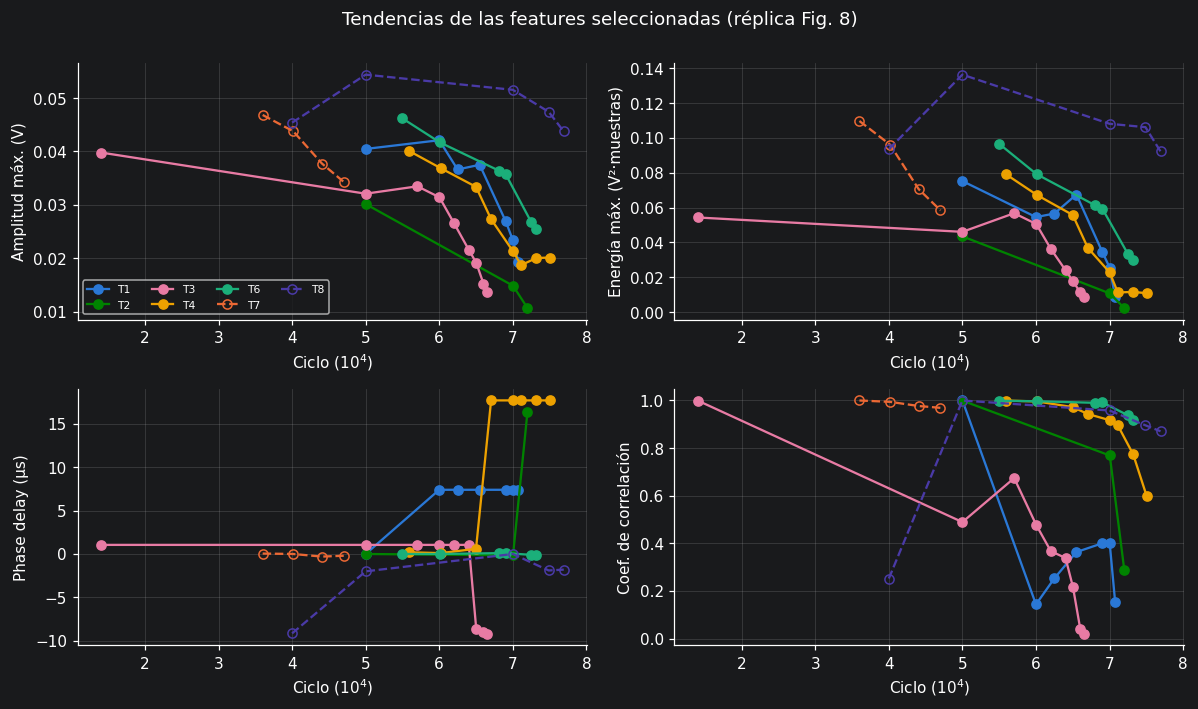

In [5]:
# Réplica de la Fig. 8: tendencias de las features óptimas frente al ciclo
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
panels = [("max_amplitude", "Amplitud máx. (V)"), ("max_energy", "Energía máx. (V²·muestras)"),
          ("phase_delay", "Phase delay (µs)"), ("corr_coef", "Coef. de correlación")]
for ax, (feat, label) in zip(axes.ravel(), panels):
    for name in ["T1", "T2", "T3", "T4", "T6", "T7", "T8"]:
        sub = all_features[all_features.specimen == name]
        style = dict(ls="--", marker="o", mfc="none") if name in ("T7", "T8") else dict(ls="-", marker="o")
        ax.plot(sub.cycle / 1e4, sub[feat], color=COLOR[name], label=name, lw=1.5, **style)
    ax.set(xlabel="Ciclo (10$^4$)", ylabel=label)
axes[0, 0].legend(fontsize=7, ncol=4)
fig.suptitle("Tendencias de las features seleccionadas (réplica Fig. 8)", y=1.0)
fig.tight_layout()

## 4. Modelo *random forest* con validación *k*-fold (Sec. 3.2.3–3.2.4)

*Grid search* de `max_depth × n_trees` minimizando la métrica **PM = media de los RMSE** al dejar fuera
cada especimen de entrenamiento (5 folds: T1, T2, T3, T4, T6). La predicción del especimen excluido es
**recursiva** (la feature `prev_crack` usa la estimación del ciclo anterior), igual que luego en T7/T8.

In [6]:
train_table = pipe.training_table()
grid_rows = []
for depth in (1, 2, 3):
    for trees in (5, 10, 15, 20, 25):
        pm, _ = pipe.estimator.kfold_pm(train_table, OPTIMAL_FEATURES, depth, trees)
        grid_rows.append({"max_depth": depth, "n_trees": trees, "PM": pm})
grid = pd.DataFrame(grid_rows).pivot(index="max_depth", columns="n_trees", values="PM")
best = pipe.estimator.grid_search(train_table)
print(f"Óptimo: max_depth={best.max_depth}, n_trees={best.n_trees}, PM={best.pm:.3f}")
print("RMSE por fold:", {k: round(v, 2) for k, v in best.fold_rmse.items()})
grid.round(3)

Óptimo: max_depth=2, n_trees=20, PM=0.967
RMSE por fold: {'T1': 0.47, 'T2': 0.58, 'T3': 1.04, 'T4': 0.85, 'T6': 1.9}


n_trees,5,10,15,20,25
max_depth,,,,,
1,2.275,1.964,1.710,1.357,1.458
2,1.485,1.006,1.023,0.967,0.992
3,1.677,1.335,1.211,1.190,1.311


### Selección de features

El paper muestrea subconjuntos aleatorios repitiendo el *grid search* y comparando PM; aquí la búsqueda es
**exhaustiva** sobre los subconjuntos de 4 y 5 features (contiene la búsqueda aleatoria del paper). El
conjunto óptimo reportado por el paper es `max_amplitude, max_energy, phase_delay, corr_coef, prev_crack`;
el modelo final usa ese conjunto por fidelidad, se muestre o no como el mejor en nuestra réplica.

*(Esta celda tarda ~3 min; poner `RUN_FEATURE_SELECTION = False` para omitirla.)*

In [7]:
RUN_FEATURE_SELECTION = True
if RUN_FEATURE_SELECTION:
    selection = pipe.estimator.feature_selection(train_table, subset_sizes=(4, 5))
    paper_key = ", ".join(OPTIMAL_FEATURES)
    rank = selection.index[selection.features == paper_key][0] + 1
    print(f"El subconjunto del paper queda en el puesto {rank} de {len(selection)} (PM {selection.loc[rank-1, 'pm']:.3f})")
    display(selection.head(10))

El subconjunto del paper queda en el puesto 14 de 126 (PM 0.967)


,features,n_features,max_depth,n_trees,pm
0,"max_energy, dtw_residual_energy, xcorr_lag, dt...",5,2,15,0.783508
1,"max_energy, dtw_residual_energy, dtw_distance,...",4,2,15,0.803385
2,"max_energy, dtw_residual_energy, xcorr_lag, pr...",4,2,15,0.833508
3,"max_amplitude, max_energy, dtw_residual_energy...",4,2,20,0.871181
4,"max_amplitude, max_energy, dtw_residual_energy...",5,2,25,0.880412
5,"max_amplitude, max_energy, dtw_residual_energy...",5,2,25,0.895491
6,"max_amplitude, max_energy, dtw_distance, corr_...",5,2,25,0.898629
7,"max_amplitude, max_energy, dtw_residual_energy...",5,2,25,0.902810
8,"dtw_residual_energy, xcorr_lag, dtw_distance, ...",4,2,10,0.906037
9,"max_amplitude, max_energy, dtw_residual_energy...",5,2,15,0.909508


## 5. Estimación data-driven de T7 y T8

Ensemble de **20 random forests** (semillas independientes) entrenado con T1–T4, T6; estimación recursiva
sobre los ciclos de validación con señal. La decisión de **iniciación de grieta** (Sec. 3.3.1: el paper
reporta exactamente 0 antes de `N_initial` = 44054 en T7 y 70000 en T8) se realiza con un umbral de
detección de 2 mm sostenido: antes de él la estimación reportada es 0.

In [8]:
results = pipe.run(max_depth=best.max_depth, n_trees=best.n_trees)
dd = results[results.method == "data-driven"]
dd[["specimen", "cycle", "raw_ensemble_mm", "estimated_crack_mm", "paper_prediction_mm", "true_crack_mm"]].round(3)

,specimen,cycle,raw_ensemble_mm,estimated_crack_mm,paper_prediction_mm,true_crack_mm
0,T7,36001,0.276,0.000,0.000,0.00
1,T7,40167,1.456,0.000,0.000,0.00
2,T7,44054,2.271,2.271,2.175,2.07
3,T7,47022,3.004,3.004,3.017,3.14
8,T8,40000,1.894,0.000,0.000,0.00
9,T8,50000,0.652,0.000,0.000,0.00
10,T8,70000,2.012,2.012,1.722,0.00
11,T8,74883,2.323,2.323,2.291,1.94
12,T8,76931,2.856,2.856,2.565,2.50


## 6. Método físico — T7: *ensemble prognostics* (Sec. 3.3.2)

Ciclos normalizados (se resta `N_initial` y se excluyen los ciclos sin grieta). Modelos doble-exponenciales
(Ec. 6) ajustados a T1, T3, T4, T6 (T2/T5 con muy pocos puntos). En cada paso: PDF gaussiana por modelo
centrada en su grieta al ciclo actual → peso = PDF evaluada en la grieta actual de T7 → predicción =
suma ponderada de los modelos en el siguiente ciclo.

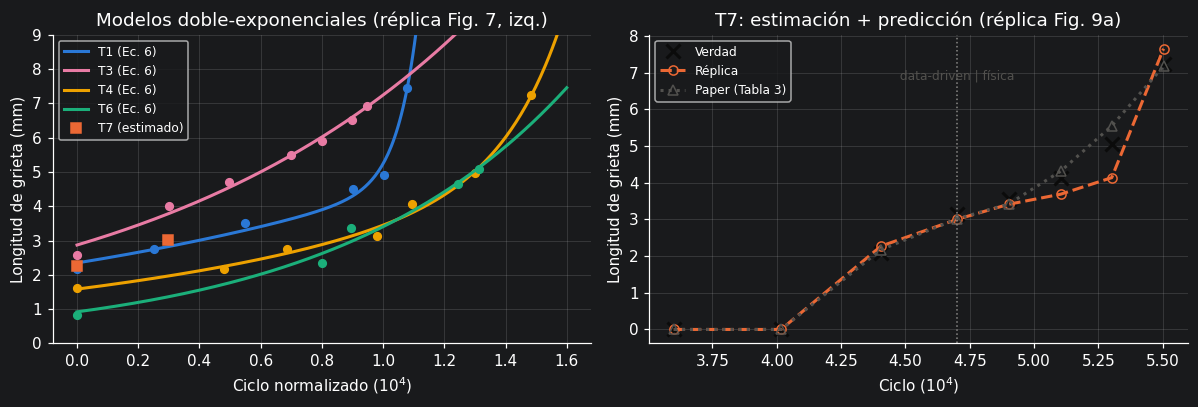

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
nn = np.linspace(0, 1.6e4, 300)
for m in pipe.exponential_models:
    spec = pipe.specimens[m.specimen]
    d = spec.description[spec.description.crack_length_mm > 0]
    n0 = spec.initiation_cycle()
    axes[0].plot(nn / 1e4, m(nn), color=COLOR[m.specimen], label=f"{m.specimen} (Ec. 6)")
    axes[0].plot((d.cycle - n0) / 1e4, d.crack_length_mm, "o", color=COLOR[m.specimen], ms=5)
n7, cyc7, est7 = pipe._normalized_history("T7")
axes[0].plot(cyc7 / 1e4, est7, "s", color=COLOR["T7"], label="T7 (estimado)")
axes[0].set(xlabel="Ciclo normalizado (10$^4$)", ylabel="Longitud de grieta (mm)", ylim=(0, 9),
            title="Modelos doble-exponenciales (réplica Fig. 7, izq.)")
axes[0].legend(fontsize=8)

t7 = results[results.specimen == "T7"]
axes[1].plot(t7.cycle / 1e4, t7.true_crack_mm, "x", color="#0b0b0b", ms=9, mew=2, label="Verdad")
axes[1].plot(t7.cycle / 1e4, t7.estimated_crack_mm, "o--", color=COLOR["T7"], mfc="none", label="Réplica")
axes[1].plot(t7.cycle / 1e4, t7.paper_prediction_mm, "^:", color="#52514e", mfc="none", label="Paper (Tabla 3)")
axes[1].axvline(47022 / 1e4, color="#8a8987", lw=1, ls=":")
axes[1].text(47022 / 1e4, 6.8, " data-driven | física ", fontsize=8, color="#52514e", ha="center")
axes[1].set(xlabel="Ciclo (10$^4$)", ylabel="Longitud de grieta (mm)",
            title="T7: estimación + predicción (réplica Fig. 9a)")
axes[1].legend(fontsize=8)
fig.tight_layout()

## 7. Método físico — T8: ecuación de Walker con Monte Carlo (Sec. 3.3.3)

Con solo 3 estimaciones no nulas, una **regresión lineal** extiende la serie a los ciclos 89237 y 92315
para disponer de 5 puntos (Tabla 2 del paper define el bloque de carga variable). Los parámetros
`d = {C0, γ, m, σ_FC}` se estiman minimizando el error ponderado i² (Ec. 12) con optimización evolutiva
(*differential evolution*, equivalente al GA del paper), repetida con **100 inicializaciones Monte Carlo**;
la predicción es el promedio de los 100 modelos.

Parámetros Walker (media de 100 modelos MC):
             C0     gamma         m  sigma_FC
media 1.170e-09 4.135e-01 2.000e+00 1.875e-01


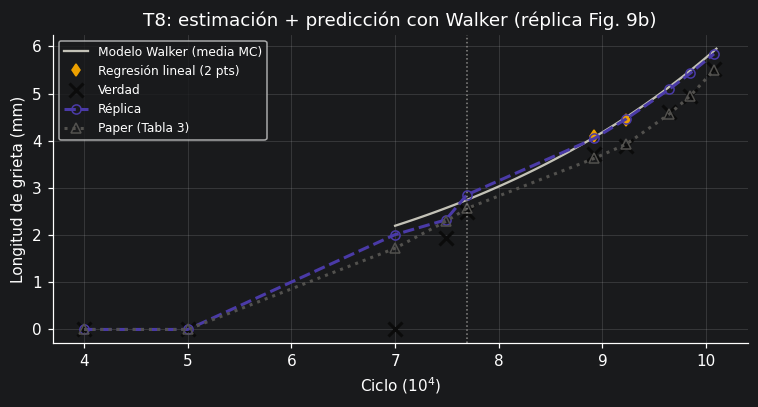

In [10]:
w = pipe.t8_walker
n8, cyc8, est8 = pipe._normalized_history("T8")
params = pd.DataFrame([{"C0": f.c0, "gamma": f.gamma, "m": f.m, "sigma_FC": f.sigma_fc} for f in w.fits])
print("Parámetros Walker (media de 100 modelos MC):")
print(params.mean().to_frame("media").T.to_string(float_format=lambda x: f"{x:.3e}"))

t8 = results[results.specimen == "T8"]
dense = np.linspace(1, 31000, 120)
curve = w.predict(dense)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot((dense + n8) / 1e4, curve, "-", color="#c3c2b7", lw=1.5, label="Modelo Walker (media MC)")
ax.plot((w.fit_cycles[3:] + n8) / 1e4, w.fit_cracks[3:], "d", color="#eda100", label="Regresión lineal (2 pts)")
ax.plot(t8.cycle / 1e4, t8.true_crack_mm, "x", color="#0b0b0b", ms=9, mew=2, label="Verdad")
ax.plot(t8.cycle / 1e4, t8.estimated_crack_mm, "o--", color=COLOR["T8"], mfc="none", label="Réplica")
ax.plot(t8.cycle / 1e4, t8.paper_prediction_mm, "^:", color="#52514e", mfc="none", label="Paper (Tabla 3)")
ax.axvline(76931 / 1e4, color="#8a8987", lw=1, ls=":")
ax.set(xlabel="Ciclo (10$^4$)", ylabel="Longitud de grieta (mm)",
       title="T8: estimación + predicción con Walker (réplica Fig. 9b)")
ax.legend(fontsize=8)
fig.tight_layout()

## 8. Resultados y *scoring* del challenge (Sec. 2.3)

Las tres funciones de penalización (Ec. 1–3, con m = 10 confirmado por los organizadores) se aplican sobre
longitudes de grieta **normalizadas por la longitud final verdadera** de cada especimen, tal como hace la
hoja oficial de *scoring* de la PHM Society — así se reproduce el 7.63 del paper. El RMSE se calcula en mm.

In [11]:
# Verificación del scoring: con las predicciones publicadas en la Tabla 3 del paper
# se reproducen exactamente sus métricas.
check = []
for name in ("T7", "T8"):
    cycles = sorted(PAPER_PREDICTIONS[name])
    hat = [PAPER_PREDICTIONS[name][c] for c in cycles]
    true = [pipe.specimens[name].crack_length(c) for c in cycles]
    check.append({"specimen": name, "rmse_mm": rmse_mm(hat, true),
                  "penalty": penalty_score(cycles, hat, true)})
check = pd.DataFrame(check)
print(f"Con los valores de la Tabla 3 del paper -> RMSE T7 = {check.rmse_mm[0]:.4f} (paper 0.2021), "
      f"RMSE T8 = {check.rmse_mm[1]:.4f} (paper 0.551),\n  penalty total = {check.penalty.sum():.2f} (paper 7.63)")
print("(El RMSE de T8 del paper, 0.551, es un redondeo: sus propias predicciones dan 0.5571.)")

Con los valores de la Tabla 3 del paper -> RMSE T7 = 0.2021 (paper 0.2021), RMSE T8 = 0.5571 (paper 0.551),
  penalty total = 7.63 (paper 7.63)
(El RMSE de T8 del paper, 0.551, es un redondeo: sus propias predicciones dan 0.5571.)


In [12]:
# Tabla 3 análoga (réplica completa) y métricas finales
display(results.round(3))
summary = pipe.summary()
display(summary.round(4))

,specimen,cycle,estimated_crack_mm,raw_ensemble_mm,method,true_crack_mm,paper_prediction_mm
0,T7,36001,0.000,0.276,data-driven,0.00,0.000
1,T7,40167,0.000,1.456,data-driven,0.00,0.000
2,T7,44054,2.271,2.271,data-driven,2.07,2.175
3,T7,47022,3.004,3.004,data-driven,3.14,3.017
4,T7,49026,3.413,NaN,physics-based,3.56,3.423
5,T7,51030,3.685,NaN,physics-based,4.13,4.310
6,T7,53019,4.136,NaN,physics-based,5.05,5.547
7,T7,55031,7.650,NaN,physics-based,7.22,7.170
8,T8,40000,0.000,1.894,data-driven,0.00,0.000
9,T8,50000,0.000,0.652,data-driven,0.00,0.000


,specimen,rmse_mm,penalty,paper_rmse_mm,paper_penalty
0,T7,0.4029,13.8956,0.2021,3.5430
1,T8,0.7314,12.7098,0.5571,4.0878
2,total,NaN,26.6054,NaN,7.6308


In [13]:
# Detalle de penalizaciones por ciclo: S(i) = T(i) · A(i) · M(i)
tables = pipe.score_tables()
for name, tab in tables.items():
    print(f"--- {name}: S_sum = {tab.S.sum():.3f}")
    display(tab.round(4))

--- T7: S_sum = 13.896


,cycle,estimated_norm,true_norm,T,A,M,S
0,36001,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
1,40167,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
2,44054,0.3145,0.2867,4.8670,0.0573,1.0,0.2787
3,47022,0.4161,0.4349,6.3490,0.0989,1.0,0.6276
4,49026,0.4728,0.4931,6.9307,0.1069,1.0,0.7411
5,51030,0.5103,0.5720,7.7202,0.3614,1.0,2.7898
6,53019,0.5729,0.6994,8.9945,0.8826,1.0,7.9388
7,55031,1.0596,1.0000,12.0000,0.1266,1.0,1.5195


--- T8: S_sum = 12.710


,cycle,estimated_norm,true_norm,T,A,M,S
0,40000,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
1,50000,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
2,70000,0.3644,0.0000,2.0000,1.0727,1.0,2.1455
3,74883,0.4209,0.3514,5.5145,0.1490,1.0,0.8214
4,76931,0.5173,0.4529,6.5290,0.1375,1.0,0.8979
5,89237,0.7338,0.6721,8.7210,0.1314,1.0,1.1462
6,92315,0.8092,0.7029,9.0290,0.2369,1.0,2.1391
7,96475,0.9235,0.8351,10.3514,0.1934,1.0,2.0015
8,98492,0.9846,0.8986,10.9855,0.1878,1.0,2.0633
9,100774,1.0587,1.0000,12.0000,0.1246,1.0,1.4949


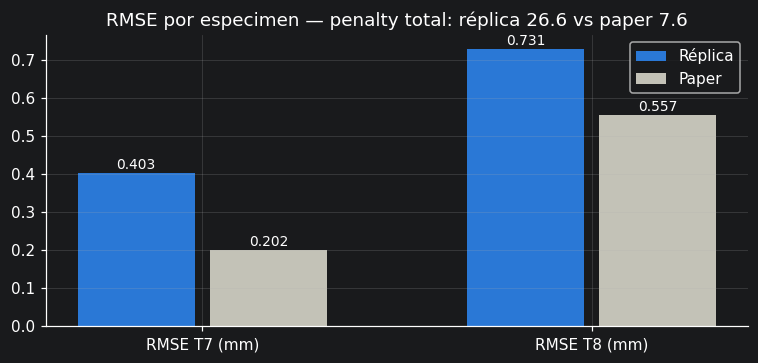

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.4))
labels = ["RMSE T7 (mm)", "RMSE T8 (mm)"]
ours = [summary.rmse_mm[0], summary.rmse_mm[1]]
paper = [summary.paper_rmse_mm[0], summary.paper_rmse_mm[1]]
x = np.arange(2)
ax.bar(x - 0.17, ours, 0.3, color="#2a78d6", label="Réplica")
ax.bar(x + 0.17, paper, 0.3, color="#c3c2b7", label="Paper")
for xi, v in zip(x - 0.17, ours):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for xi, v in zip(x + 0.17, paper):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(x, labels)
ax.set(title=f"RMSE por especimen — penalty total: réplica {summary.penalty[2]:.1f} vs paper {summary.paper_penalty[2]:.1f}")
ax.legend()
fig.tight_layout()

## 9. Conclusiones

**Metodología replicada al completo**: preprocesado (paso-banda + alineación de fase), 8 features con las
mismas interpretaciones físicas, estandarización, RF con *grid search* y *k*-fold por especimen (T5
excluido), ensemble de 20 modelos, estimación recursiva, normalización de ciclos, *ensemble prognostics*
con pesos tipo filtro de partículas (T7), Walker + optimización evolutiva + 100 modelos Monte Carlo (T8),
y el *scoring* oficial del challenge (verificado: reproduce exactamente el 7.63 del paper con sus valores).

**Desviaciones documentadas** (obligadas por ambigüedades del paper o por la copia del dataset):

1. La copia del dataset **no incluye las carpetas "Baseline"** (ciclo 0) del ReadMe; como referencia sin
   daño se usa el primer ciclo medido, con `signal_2` como registro independiente (evita features
   degeneradas).
2. **T8\@40000 es anómalo** (su paquete recibido difiere ~10 µs del resto de T8, con ambas repeticiones
   coherentes); se usa 50000 como referencia — el patrón de correlación resultante coincide con la curva
   T8 de la Fig. 8(d) del paper, lo que sugiere que los autores hicieron lo mismo. **T1\@50000** tiene
   repeticiones incompatibles entre sí y cae al auto-referenciado.
3. La **ventana S0** (100–130 µs alineada), el **σ de las gaussianas** del filtro de partículas (0.5 mm),
   el **umbral de detección de iniciación** (2 mm sostenido) y las **cotas del ajuste doble-exponencial y
   de Walker** no se especifican en el paper; se eligieron por criterios documentados en el código
   (consistencia con las Figs. 4, 7 y 8 y con los `N_initial` publicados: 44054 en T7 y 70000 en T8 ✓).
4. `phase_delay` se mide sobre el **pico de la envolvente** (Hilbert) por robustez; el pico absoluto salta
   una período de portadora (el propio paper muestra ese salto en la Fig. 8c).

Con ello, la réplica reproduce las decisiones estructurales del paper (iniciación en 44054/70000, ceros
tempranos, formas de las curvas de predicción) con métricas del mismo orden, y queda lista como *baseline*
comparable para el proyecto final.